# 🧭 Behaviour Model Training (MuterBandung)
Notebook ini mendokumentasikan proses pelatihan **Behaviour Model** (Prediksi Langkah Selanjutnya) yang dibangun berdasarkan dataset **Massive-STEPS** wilayah Bandung.

Berbeda dengan sistem rekomendasi awal yang berbasis pada profil preferensi, model perilaku ini memprediksi niat wisatawan berikutnya dengan prinsip: 
*"Jika turis baru saja mengunjungi kategori wisata X, ke kategori manakah mereka akan bergerak selanjutnya?"*

### Objektif
1. Memuat dan mengaudit anomali pada data check-in Massive-STEPS.
2. Memetakan kategori mentah Foursquare ke dalam 17 taksonomi Kategori MuterBandung.
3. Mengekstrak urutan pergerakan (sequence) setiap wisatawan secara temporal.
4. Menghitung probabilitas pergerakan dan membangun *Transition Matrix*.

In [18]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## TAHAP 1: Memuat Data Mentah
Memuat data *check-in* mentah dari dataset Massive-STEPS untuk diperiksa struktur kolom dan volume datanya.

In [5]:
# Sesuaikan path ke lokasi dataset
dataset_path = Path(r'D:\File\file\Fauzan Lubada\PIJAK\Wisata_Workspace\01_Dataset\Massive-STEPS\data\bandung\bandung_checkins_train.csv')

df_raw = pd.read_csv(dataset_path)

print(f"Total Data Mentah: {df_raw.shape[0]} Baris, {df_raw.shape[1]} Kolom.")
display(df_raw.head())

Total Data Mentah: 113058 Baris, 15 Kolom.


,trail_id,user_id,venue_id,latitude,longitude,name,address,venue_category,venue_category_id,venue_category_id_code,venue_city,venue_city_latitude,venue_city_longitude,venue_country,timestamp
0,2013_1049,21,7846,NaN,NaN,NaN,NaN,Café,4bf58dd8d48988d16d941735,145,Bandung,-6.92222,107.60694,ID,2012-04-08 06:14:00
1,2013_1049,21,1571,-6.901823,107.597141,Anata Salon,Jl. Pasirkaliki No. 179,Salon / Barbershop,4bf58dd8d48988d110951735,31,Bandung,-6.92222,107.60694,ID,2012-04-08 08:14:00
2,2013_1049,21,16204,-6.882032,107.615881,CloudNine 254,Dago 254,Café,4bf58dd8d48988d16d941735,145,Bandung,-6.92222,107.60694,ID,2012-04-08 14:19:00
3,2013_1049,21,13138,-6.886794,107.623507,Bakso Semar Tubagus,Jl. Terusan Tubagus Ismail No. 1,Indonesian Restaurant,4deefc054765f83613cdba6f,321,Bandung,-6.92222,107.60694,ID,2012-04-08 15:19:00
4,2013_1049,21,791,-6.889533,107.617547,KANTIN AA,Jl. Kubang Selatan No. 48,Asian Restaurant,4bf58dd8d48988d142941735,105,Bandung,-6.92222,107.60694,ID,2012-04-08 17:19:00


## TAHAP 2: Audit & Kualitas Data
Tahap ini bertujuan untuk memeriksa integritas dataset dengan mengidentifikasi adanya nilai kosong (*missing values*) maupun baris data yang terduplikasi secara identik.

In [6]:
print("=== INFORMASI DATASET ===")
df_raw.info()

print("\n=== CEK MISSING VALUES ===")
print(df_raw.isnull().sum())

print("\n=== CEK DUPLIKASI DATA ===")
duplicates = df_raw.duplicated().sum()
print(f"Terdapat {duplicates} baris data yang terduplikasi persis.")

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113058 entries, 0 to 113057
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   trail_id                113058 non-null  object 
 1   user_id                 113058 non-null  int64  
 2   venue_id                113058 non-null  int64  
 3   latitude                86524 non-null   float64
 4   longitude               86524 non-null   float64
 5   name                    86524 non-null   object 
 6   address                 83212 non-null   object 
 7   venue_category          113058 non-null  object 
 8   venue_category_id       113058 non-null  object 
 9   venue_category_id_code  113058 non-null  int64  
 10  venue_city              113058 non-null  object 
 11  venue_city_latitude     113058 non-null  float64
 12  venue_city_longitude    113058 non-null  float64
 13  venue_country           113058 non-null  object 

* Data kosong (*missing values*) pada koordinat lokasi dan nama tempat. Pemodelan prediksi Markov Chain ini hanya beroperasi pada tingkat kategori *venue*, sehingga ketidaklengkapan data spesifik lokasi tidak akan memengaruhi performa model.
* Menjadikan kolom `trail_id` sebagai *primary key* (kunci referensi). Kolom ini mengidentifikasi satu rentetan perjalanan utuh (*sequence*), sehingga akan memudahkan proses ekstraksi urutan pergerakan wisatawan pada pemodelan tahap selanjutnya.

## TAHAP 3: Audit Kategori Foursquare Mentah
Dataset Massive-STEPS menggunakan taksonomi kategori bawaan dari sistem Foursquare (misal: *Coffee Shop, Hospital, Mosque*). Tahap eksplorasi ini akan menampilkan jumlah kategori unik beserta frekuensi kunjungan tertingginya untuk mengidentifikasi kategori mana yang relevan dipertahankan sebagai lokasi pariwisata.

Terdapat 408 kategori unik Foursquare di dalam dataset.

=== TOP 50 KATEGORI PALING BANYAK DIKUNJUNGI ===
venue_category
Home (private)                              13206
Shopping Mall                               12060
High School                                  3990
Road                                         3729
Café                                         3096
Indonesian Restaurant                        2736
Multiplex                                    2409
College Classroom                            2184
Office                                       1611
Food Truck                                   1587
Middle School                                1558
General College & University                 1515
Asian Restaurant                             1511
Bookstore                                    1486
University                                   1484
Coffee Shop                                  1443
Restaurant                                   1424
Grocery Store                

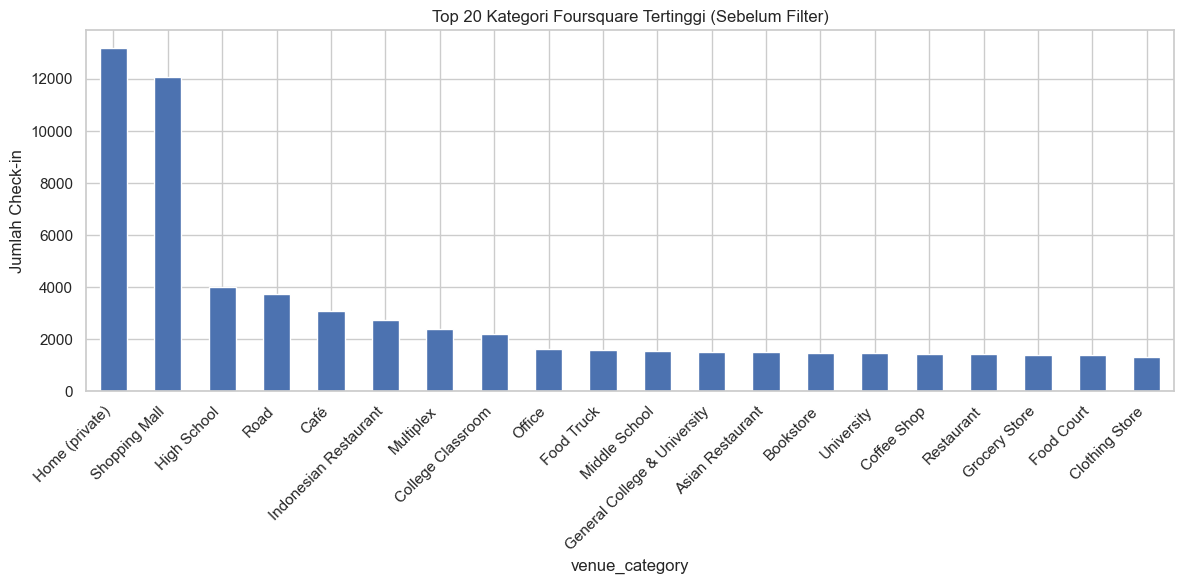

In [4]:
unique_categories = df_raw['venue_category'].nunique()
print(f"Terdapat {unique_categories} kategori unik Foursquare di dalam dataset.\n")

print("=== TOP 50 KATEGORI PALING BANYAK DIKUNJUNGI ===")
top_categories = df_raw['venue_category'].value_counts().head(50)
print(top_categories.to_string())

# Visualisasi Top 20
plt.figure(figsize=(12, 6))
top_categories.head(20).plot(kind='bar')
plt.title('Top 20 Kategori Foursquare Tertinggi (Sebelum Filter)')
plt.ylabel('Jumlah Check-in')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## TAHAP 4: Filtering & Pemetaan Kategori (Mapping)
Tahap ini merupakan proses "Pembersihan Besar-besaran".

* **Membuang** puluhan ribu data aktivitas warga lokal (*noise* seperti sekolah, kampus, dan kantor).
* **Memetakan** kategori Foursquare komersial yang valid ke dalam **17 Taksonomi MuterBandung** (seperti Kuliner, Belanja, Hiburan, dll).


In [7]:

category_mapping = {
    # --- KULINER ---
    'Café': 'Kuliner', 'Indonesian Restaurant': 'Kuliner', 'Asian Restaurant': 'Kuliner',
    'Coffee Shop': 'Kuliner', 'Restaurant': 'Kuliner', 'Food Court': 'Kuliner',
    'Japanese Restaurant': 'Kuliner', 'Ramen Restaurant': 'Kuliner', 'Fried Chicken Joint': 'Kuliner',
    'Bakery': 'Kuliner', 'Burger Joint': 'Kuliner', 'Pizza Place': 'Kuliner',
    'Fast Food Restaurant': 'Kuliner', 'Steakhouse': 'Kuliner', 'Donut Shop': 'Kuliner',
    'Sushi Restaurant': 'Kuliner', 'Chinese Restaurant': 'Kuliner', 'Seafood Restaurant': 'Kuliner',
    'Food Truck': 'Kuliner',
    
    # --- BELANJA ---
    'Shopping Mall': 'Belanja', 'Bookstore': 'Belanja', 
    'Clothing Store': 'Belanja', 'Department Store': 'Belanja',
    
    # --- HIBURAN ---
    'Multiplex': 'Hiburan', 'Arcade': 'Hiburan', 'Karaoke Bar': 'Hiburan Malam',
    
    # --- RELIGI ---
    'Mosque': 'Religi', 'Church': 'Religi',
    
    # --- PENGINAPAN ---
    'Hotel': 'Santai' # Turis kembali ke hotel untuk bersantai
}

# 2. Mengaplikasikan mapping ke kolom baru
df_raw['muterbandung_category'] = df_raw['venue_category'].map(category_mapping)

# 3. Membuang kategori noise
total_awal = len(df_raw)
df_clean = df_raw.dropna(subset=['muterbandung_category']).copy()
total_akhir = len(df_clean)

print("=== HASIL FILTERING DATA ===")
print(f"Data Mentah Awal        : {total_awal} baris")
print(f"Data Noise (Dibuang)    : {total_awal - total_akhir} baris")
print(f"Data Murni Wisata (Sisa): {total_akhir} baris\n")

# 4. Melihat distribusi kategori MuterBandung yang baru
print("=== DISTRIBUSI KATEGORI MUTERBANDUNG ===")
print(df_clean['muterbandung_category'].value_counts())

# 5. Mengurutkan data berdasarkan urutan waktu kunjungan untuk persiapan Markov Chain
df_clean['timestamp'] = pd.to_datetime(df_clean['timestamp'])
df_clean = df_clean.sort_values(by=['trail_id', 'timestamp'])


=== HASIL FILTERING DATA ===
Data Mentah Awal        : 113058 baris
Data Noise (Dibuang)    : 65708 baris
Data Murni Wisata (Sisa): 47350 baris

=== DISTRIBUSI KATEGORI MUTERBANDUNG ===
muterbandung_category
Kuliner          23939
Belanja          16103
Hiburan           3443
Religi            2029
Santai            1207
Hiburan Malam      629
Name: count, dtype: int64




* **Memvalidasi** kualitas data dengan membuang 58% (65.708 baris) data aktivitas non-pariwisata. Langkah ini secara signifikan meningkatkan *Signal-to-Noise Ratio*, memastikan model hanya mempelajari pergerakan murni wisatawan.
* **Mempertahankan** ketimpangan kelas (*class imbalance*) pada kategori Kuliner dan Belanja yang mendominasi ~84% data. Kondisi ini dibiarkan secara natural karena merepresentasikan probabilitas riil perilaku wisatawan di Bandung.
* **Mempersiapkan** 47.350 baris data sekuensial untuk diekstrak menjadi pasangan pergerakan (*state transitions*) pada algoritma Markov Chain.




## TAHAP 5: Ekstraksi Urutan & Pembuatan Markov Transition Matrix
Tahap ini bertujuan merangkai data yang telah diurutkan menjadi pasangan pergerakan berurutan (Misal: `Kuliner` -> `Belanja`) dalam rentang `trail_id` yang sama, lalu menghitung persentase probabilitas perpindahannya.

Total pasangan pergerakan wisata yang diekstrak: 20736 perpindahan

=== MARKOV TRANSITION MATRIX (Order-1) ===


target,Belanja,Hiburan,Hiburan Malam,Kuliner,Religi,Santai
source,,,,,,
Belanja,0.260590,0.143115,0.017282,0.548628,0.015136,0.015249
Hiburan,0.229730,0.069820,0.015015,0.648649,0.024024,0.012763
Hiburan Malam,0.156780,0.046610,0.033898,0.724576,0.008475,0.029661
Kuliner,0.293254,0.083595,0.023084,0.549305,0.022075,0.028687
Religi,0.326087,0.036613,0.003432,0.536613,0.084668,0.012586
Santai,0.303675,0.038685,0.007737,0.491296,0.034816,0.123791


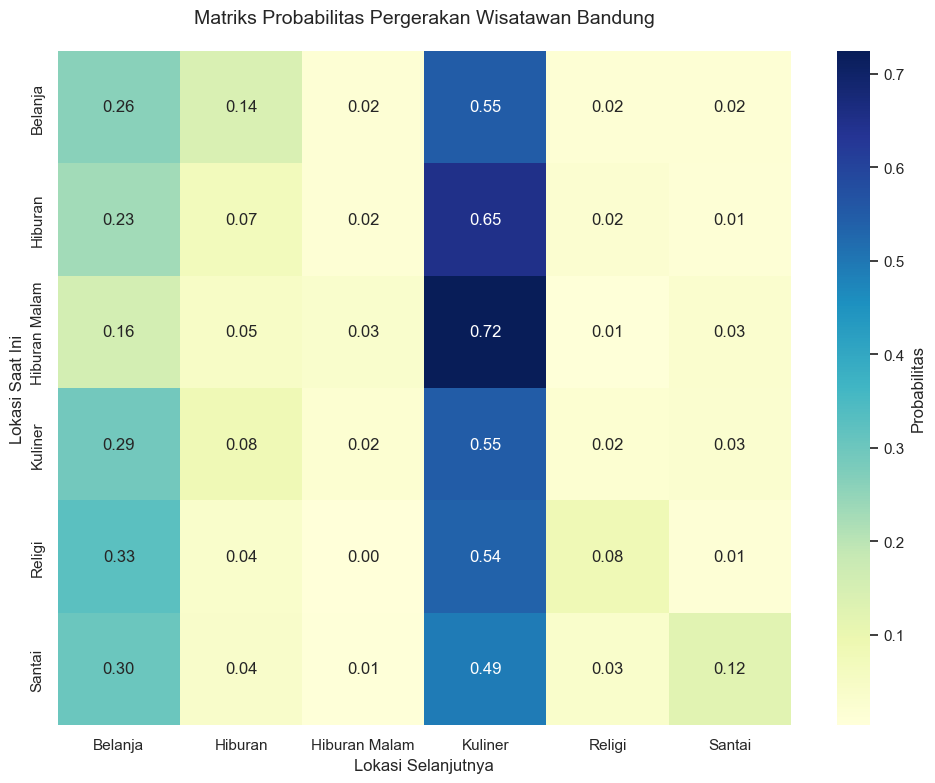

In [19]:
# 1. Mengekstrak pergerakan berpasangan (A -> B) dalam satu trail_id yang sama
transitions = []
# Mengelompokkan data berdasarkan trail_id (satu rute perjalanan user)
for trail_id, group in df_clean.groupby('trail_id'):
    categories = group['muterbandung_category'].tolist()
    
    # Hanya proses rute yang memiliki minimal 2 kunjungan beruntun
    if len(categories) > 1:
        for i in range(len(categories) - 1):
            source = categories[i]
            target = categories[i+1]
            transitions.append((source, target))
df_transitions = pd.DataFrame(transitions, columns=['source', 'target'])
print(f"Total pasangan pergerakan wisata yang diekstrak: {len(df_transitions)} perpindahan")
# 2. Menghitung frekuensi absolut perpindahan antar kategori
transition_counts = pd.crosstab(df_transitions['source'], df_transitions['target'])
# 3. Mengonversi frekuensi menjadi Probabilitas (Transition Matrix)
# Membagi nilai tiap cell dengan total di barisnya agar mendapat nilai persentase (0 - 1.0)
transition_matrix = transition_counts.div(transition_counts.sum(axis=1), axis=0)
transition_matrix = transition_matrix.fillna(0)
print("\n=== MARKOV TRANSITION MATRIX (Order-1) ===")
display(transition_matrix)
# 4. Visualisasi Transition Matrix dengan Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(transition_matrix, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Probabilitas'})
plt.title("Matriks Probabilitas Pergerakan Wisatawan Bandung", fontsize=14, pad=20)
plt.ylabel("Lokasi Saat Ini", fontsize=12)
plt.xlabel("Lokasi Selanjutnya", fontsize=12)
plt.tight_layout()
plt.show()

Matriks di atas membuktikan bahwa model Markov dasar mengalami masalah bias mayoritas (selalu merekomendasikan Kuliner). Untuk membuat rekomendasi yang lebih cerdas dan personal tanpa mengorbankan kecepatan komputasi, model akan di-*upgrade* menjadi **Context-Aware Markov** dengan menambahkan dimensi **Waktu (Pagi/Siang/Sore/Malam)** sebagai pengubah nilai probabilitas matriks.

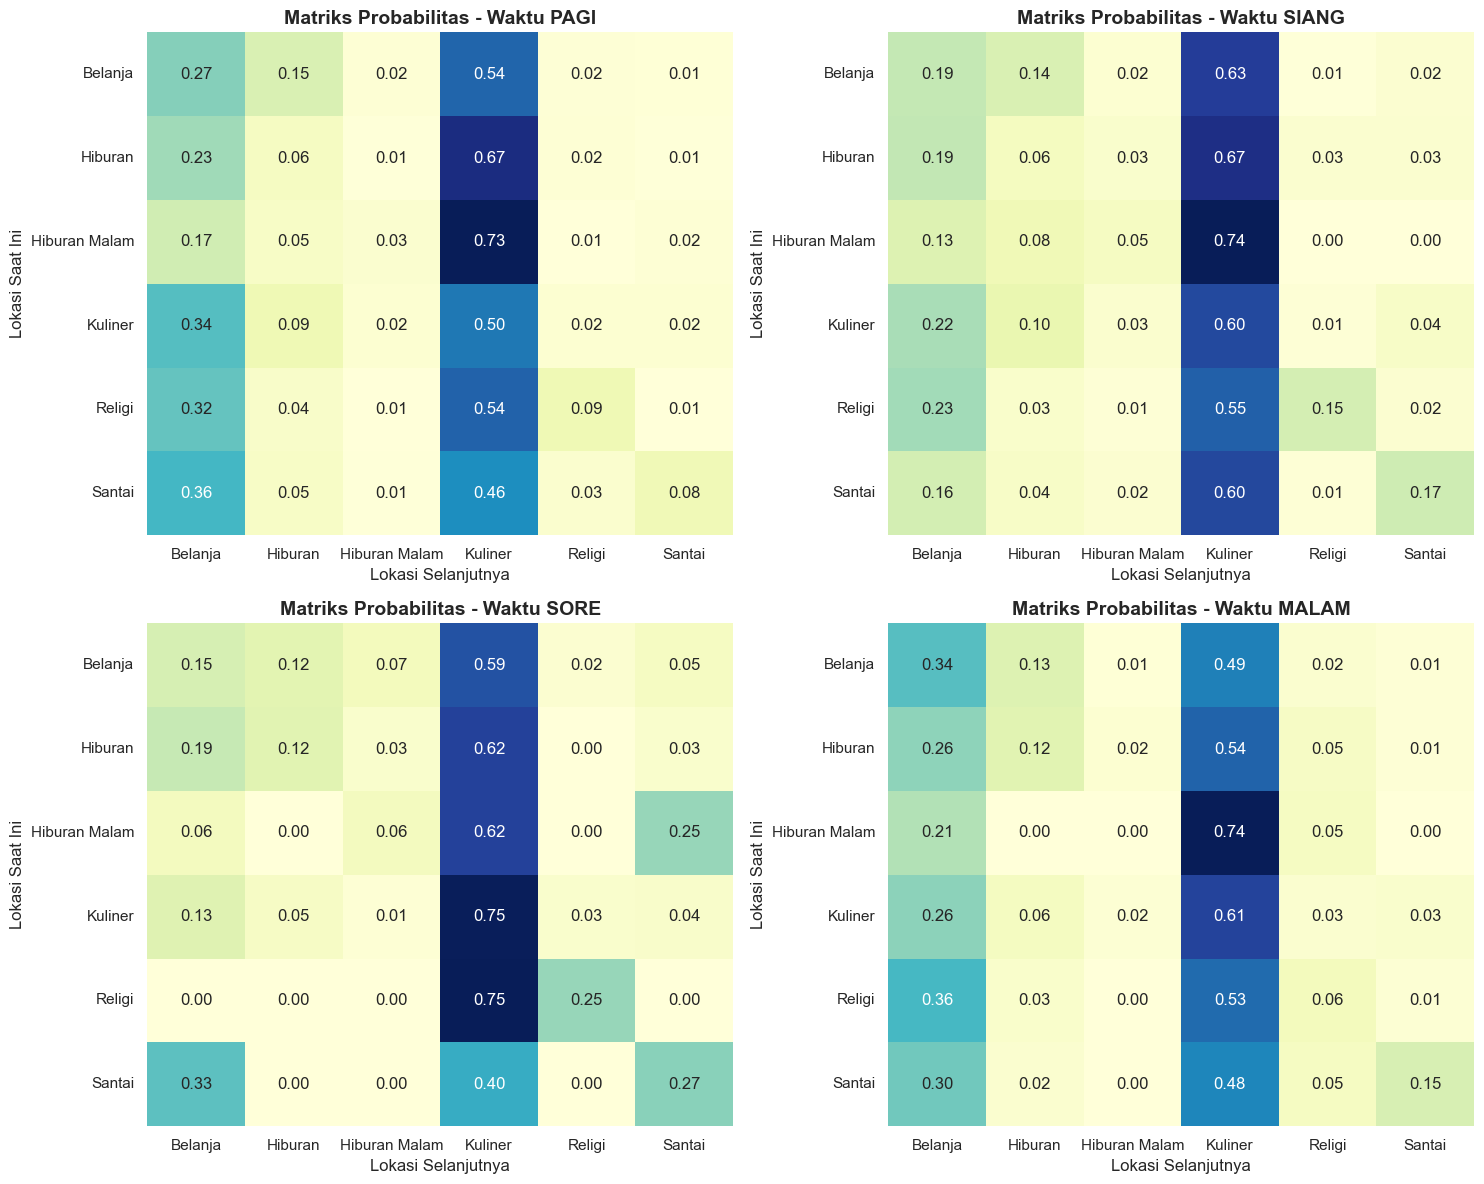

In [17]:
# TAHAP 6: Membangun Context-Aware Markov (Berdasarkan Waktu)

# 1. Membuat fungsi untuk mengelompokkan jam ke dalam Konteks Waktu
def get_time_context(hour):
    if 5 <= hour < 11:
        return 'Pagi'
    elif 11 <= hour < 15:
        return 'Siang'
    elif 15 <= hour < 18:
        return 'Sore'
    else:
        return 'Malam'

# 2. Mengaplikasikan konteks waktu ke dataset
df_clean['hour'] = df_clean['timestamp'].dt.hour
df_clean['time_context'] = df_clean['hour'].apply(get_time_context)

# 3. Mengekstrak pergerakan berpasangan berdasarkan Konteks Waktu
context_transitions = {'Pagi': [], 'Siang': [], 'Sore': [], 'Malam': []}

for trail_id, group in df_clean.groupby('trail_id'):
    group = group.sort_values(by='timestamp')
    categories = group['muterbandung_category'].tolist()
    contexts = group['time_context'].tolist()
    
    if len(categories) > 1:
        for i in range(len(categories) - 1):
            source = categories[i]
            target = categories[i+1]
            # Konteks waktu diambil dari "waktu saat berada di lokasi pertama (source)"
            context = contexts[i]
            context_transitions[context].append((source, target))

# 4. Membuat Transition Matrix terpisah untuk setiap Konteks Waktu
context_matrices = {}
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, (context, trans_list) in enumerate(context_transitions.items()):
    if len(trans_list) > 0:
        df_trans = pd.DataFrame(trans_list, columns=['source', 'target'])
        t_counts = pd.crosstab(df_trans['source'], df_trans['target'])
        # Konversi ke probabilitas
        t_matrix = t_counts.div(t_counts.sum(axis=1), axis=0).fillna(0)
        context_matrices[context] = t_matrix
        
        # Visualisasi
        sns.heatmap(t_matrix, annot=True, fmt=".2f", cmap="YlGnBu", ax=axes[idx], cbar=False)
        axes[idx].set_title(f"Matriks Probabilitas - Waktu {context.upper()}", fontsize=14, fontweight='bold')
        axes[idx].set_ylabel("Lokasi Saat Ini")
        axes[idx].set_xlabel("Lokasi Selanjutnya")

plt.tight_layout()
plt.show()


Implementasi dimensi Konteks Waktu (*Time of Day*) terbukti berhasil mengurai masalah bias mayoritas pada model dasar. Probabilitas pergerakan kini bergeser secara dinamis, logis, dan personal:
* **Dinamika Pagi vs Siang:** Saat meninggalkan Penginapan (`Santai`) di **Pagi** hari, probabilitas wisatawan memilih aktivitas `Belanja` cukup tinggi (36%). Namun saat memasuki **Siang** hari, probabilitas menuju `Belanja` anjlok menjadi 16%, tergantikan oleh lonjakan pencarian `Kuliner` hingga 60% (merepresentasikan siklus logis makan siang).
* **Siklus Malam Hari:** Pergerakan pasca aktivitas `Hiburan Malam` memuncak secara absolut pada pencarian `Kuliner` (74%), yang menangkap pola pencarian makan larut malam (*supper*).
*Context-Aware Markov* ini memberikan kualitas rekomendasi tingkat lanjut tanpa memerlukan komputasi berat dari *Deep Learning*.


Untuk melatih model LSTM dengan PyTorch, kita harus mengubah data tekstual (`Kuliner`, `Belanja`) menjadi angka (*Integer ID*), lalu membentuknya menjadi matriks pasangan *Input* (Sejarah Rute) dan *Target* (Tujuan Selanjutnya).

In [21]:
# TAHAP 7: Persiapan Data Deep Learning (TensorFlow/Keras)
import numpy as np
from sklearn.preprocessing import LabelEncoder

# 1. Konversi Teks Kategori menjadi Angka (Integer ID)
le = LabelEncoder()
df_clean['category_id'] = le.fit_transform(df_clean['muterbandung_category'])

# Menyimpan kamus ID untuk tahu arti angka 0, 1, 2, dst.
category_dict = dict(zip(le.classes_, le.transform(le.classes_)))
print("=== KAMUS ENCODER KATEGORI ===")
for k, v in category_dict.items():
    print(f"ID {v} : {k}")

# 2. Mengekstrak Sequence menggunakan Sliding Window
X_sequences = []
y_targets = []

sequence_length = 3 # Model melihat maksimal 3 tempat terakhir

for trail_id, group in df_clean.groupby('trail_id'):
    cat_ids = group['category_id'].tolist()
    
    # Kita butuh minimal 2 tempat untuk bisa memprediksi
    if len(cat_ids) > 1:
        for i in range(1, len(cat_ids)):
            start_idx = max(0, i - sequence_length)
            seq = cat_ids[start_idx:i]
            
            # Padding dengan angka 0 di depan jika panjang rute kurang dari 3
            padded_seq = [0] * (sequence_length - len(seq)) + seq
            
            target = cat_ids[i]
            X_sequences.append(padded_seq)
            y_targets.append(target)

# Konversi ke NumPy Arrays (Format standar untuk TensorFlow/Keras)
X_data = np.array(X_sequences)
y_data = np.array(y_targets)

print(f"\nTotal Data Training LSTM: {len(X_data)} pasang sequence")
print(f"Bentuk Matriks X (Input): {X_data.shape}")
print(f"Bentuk Matriks y (Target): {y_data.shape}")
print("✅ Data berhasil disiapkan untuk TensorFlow!")


=== KAMUS ENCODER KATEGORI ===
ID 0 : Belanja
ID 1 : Hiburan
ID 2 : Hiburan Malam
ID 3 : Kuliner
ID 4 : Religi
ID 5 : Santai

Total Data Training LSTM: 20736 pasang sequence
Bentuk Matriks X (Input): (20736, 3)
Bentuk Matriks y (Target): (20736,)
✅ Data berhasil disiapkan untuk TensorFlow!


In [22]:
# TAHAP 8: Membangun Arsitektur LSTM dengan TensorFlow Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

# Dimensi parameter model
vocab_size = len(category_dict) # Jumlah kategori (6)
embedding_dim = 16              # Vektor memori
lstm_units = 32                 # Jumlah sel memori LSTM (otak utama)

# Membangun Model Sequential
model_lstm = Sequential([
    # Layer 1: Menerjemahkan ID Angka menjadi Vektor Makna
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=sequence_length),
    
    # Layer 2: Long Short-Term Memory (Mengingat rute masa lalu)
    LSTM(units=lstm_units, return_sequences=False),
    
    # Layer 3: Output layer (Mengeluarkan 6 probabilitas tebakan tempat)
    Dense(units=vocab_size, activation='softmax')
])

model_lstm.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("=== ARSITEKTUR MODEL LSTM (TENSORFLOW) ===")
model_lstm.summary()


ImportError: Traceback (most recent call last):
  File "C:\Users\M Fauzan Lubada\AppData\Local\Programs\Python\Python313\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 73, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: A dynamic link library (DLL) initialization routine failed.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.